# Assessing Working Memory Capacity of ChatGPT

In [4]:
import os
import time
import random
from openai import OpenAI
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import json
import math
from tabulate import tabulate
from scipy.stats import norm, ttest_ind, f_oneway, t, shapiro, levene, mannwhitneyu, wilcoxon, kruskal
import itertools
from matplotlib.ticker import MaxNLocator

os.environ["OPENAI_API_KEY"] = ""



In [6]:

def generate_nback_sequences(n, alphabet, seq_length, matches, num_sequences):
    sequences = []
    for _ in range(num_sequences):
        seq, conditions = [], []
        match_positions = random.sample(range(n, seq_length), matches)
        match_positions.sort()

        for i in range(seq_length):
            if i in match_positions:
                seq.append(seq[i - n])
                conditions.append('m')
            else:
                random_letter = random.choice(alphabet)
                while i > n and seq[i - n] == random_letter:
                    random_letter = random.choice(alphabet)
                seq.append(random_letter)
                conditions.append('-')
        
        sequences.append((''.join(seq), ''.join(conditions)))

    return sequences

def save_sequences_to_files(folder, sequences):
    os.makedirs(folder, exist_ok=True)

    for i, (seq, conditions) in enumerate(sequences):
        with open(os.path.join(folder, f"{i}.txt"), "w") as file:
            file.write(f"{seq}\n{conditions}\n")

alphabet = 'bcdfghjklnpqrstvwxyz'
seq_length = 24
matches = 8
num_sequences = 50

for n in [1, 2, 3]:
    sequences = generate_nback_sequences(n, alphabet, seq_length, matches, num_sequences)
    folder = os.path.join("letters", f"{n}back")
    save_sequences_to_files(folder, sequences)

In [6]:
n_list = [1, 2, 3]
blocks = 50

In [8]:

# read N-back task (N=1,2,3) sequences and conditions from txt files, in which the first line is the sequence and the second line is the condition
# and create a list of trials
# each trial is a dictionary with the following keys:
# - 'stimulus': the stimulus letter
# - 'target': the desired response letter
# - 'response': the received response letter
# - 'correct': whether the response was correct
# - 'rt': the response time

all_trials = {}
for n in n_list:
    for b in range(blocks):
        path = os.path.join(os.getcwd(), 'letters','{}back'.format(n), '{}.txt'.format(b))
        with open(path, 'r') as f:
            seq = f.readline().strip()
            cond = f.readline().strip()

        # create a list of trials
        trials = []
        for i in range(len(seq)):
            trial = {}
            trial['stimulus'] = seq[i]
            trial['target'] = cond[i]
            trial['response'] = ''
            trial['correct'] = ''
            trial['rt'] = ''
            trials.append(trial)

        all_trials['{}back_{}'.format(n, b)] = trials


In [18]:
# First, we will run the 1-back task
client = OpenAI()
for b in range(blocks):
    messages = [
        {"role": "system", "content" : "You are asked to perform a 1-back task. You will see a sequence of letters. Your task is to respond with 'm' (no quotation marks, just the letter m) whenever the current letter is the same as the previous one, and '-' (no quotation marks, just the dash sign) otherwise. Only 'm' and '-' are allowed responses. No explanations needed: please don't output any extra words!! The sequence will be presented one letter at a time. Now begins the task."}
    ]
    for i in range(len(all_trials['1back_{}'.format(b)])):
        input_letter = all_trials['1back_{}'.format(b)][i]['stimulus']  # 避免使用input作为变量名
        print(f'block {b}, trial {i}: {input_letter} (target: {all_trials["1back_{}".format(b)][i]["target"]})')
        messages.append({"role": "user", "content": input_letter})

        start_time = time.time()

        completion = client.chat.completions.create(
            model="gpt-3.5-turbo",
            messages=messages
        )

        response_time = time.time() - start_time
        all_trials['1back_{}'.format(b)][i]['rt'] = response_time
        print(f"Response time: {response_time:.2f} seconds")

        chat_response = completion.choices[0].message.content
        print(f'ChatGPT: {chat_response}')

        # 改进的响应处理 - 不会抛出异常
        if chat_response == 'm':
            all_trials['1back_{}'.format(b)][i]['response'] = 'm'
            all_trials['1back_{}'.format(b)][i]['correct'] = all_trials['1back_{}'.format(b)][i]['target'] == 'm'
        elif chat_response == '-':
            all_trials['1back_{}'.format(b)][i]['response'] = '-'
            all_trials['1back_{}'.format(b)][i]['correct'] = all_trials['1back_{}'.format(b)][i]['target'] == '-'
        else:
            # 规则违反处理 - 不会中断程序
            print(f'⚠️ Rule violation! Got: "{chat_response}"')

            # 清理响应：去除空格、换行，转为小写
            cleaned = chat_response.strip().lower()

            # 智能提取
            if 'm' in cleaned:
                print('   → Found "m" in response')
                all_trials['1back_{}'.format(b)][i]['response'] = 'm'
                all_trials['1back_{}'.format(b)][i]['correct'] = all_trials['1back_{}'.format(b)][i]['target'] == 'm'
            elif '-' in cleaned:
                print('   → Found "-" in response')
                all_trials['1back_{}'.format(b)][i]['response'] = '-'
                all_trials['1back_{}'.format(b)][i]['correct'] = all_trials['1back_{}'.format(b)][i]['target'] == '-'
            else:
                # 完全无效的响应，记录错误但继续运行
                print(f'   ⚠️ No valid response found, marking as incorrect')
                all_trials['1back_{}'.format(b)][i]['response'] = f'INVALID:{chat_response[:30]}'  # 截断保存
                all_trials['1back_{}'.format(b)][i]['correct'] = False

        # 打印结果
        print('correct' if all_trials['1back_{}'.format(b)][i]['correct'] else 'incorrect')
        print('------------------------------------')

        messages.append({"role": "assistant", "content": chat_response})

    time.sleep(5)

block 0, trial 0: q (target: -)
Response time: 0.92 seconds
ChatGPT: -
correct
------------------------------------
block 0, trial 1: v (target: -)
Response time: 0.59 seconds
ChatGPT: -
correct
------------------------------------
block 0, trial 2: b (target: -)
Response time: 0.66 seconds
ChatGPT: -
correct
------------------------------------
block 0, trial 3: v (target: -)
Response time: 1.41 seconds
ChatGPT: -
correct
------------------------------------
block 0, trial 4: v (target: m)
Response time: 0.79 seconds
ChatGPT: m
correct
------------------------------------
block 0, trial 5: v (target: m)
Response time: 0.65 seconds
ChatGPT: -
incorrect
------------------------------------
block 0, trial 6: f (target: -)
Response time: 0.59 seconds
ChatGPT: -
correct
------------------------------------
block 0, trial 7: x (target: -)
Response time: 0.45 seconds
ChatGPT: -
correct
------------------------------------
block 0, trial 8: x (target: m)
Response time: 0.45 seconds
ChatGPT: m

In [19]:
# Now for the 2-back task
import json
import os
from datetime import datetime

# 创建结果目录（如果不存在）
os.makedirs('results', exist_ok=True)

# 生成一个最终结果文件
final_file = f'results/2back_results_{datetime.now().strftime("%Y%m%d_%H%M%S")}.json'

for b in range(blocks):
    messages = [
        {"role": "system", "content": "You are asked to perform a 2-back task. You will see a sequence of letters. Your task is to respond with 'm' (no quotation marks, just the letter m) whenever the current letter is the same as the letter two letters ago, and '-' (no quotation marks, just the dash sign) otherwise. Only 'm' and '-' are allowed responses. No explanations needed: please don't output any extra words!! The sequence will be presented one letter at a time. Now begins the task."}
    ]

    for i in range(len(all_trials['2back_{}'.format(b)])):
        input_letter = all_trials['2back_{}'.format(b)][i]['stimulus']
        print(f'block {b}, trial {i}: {input_letter} (target: {all_trials["2back_{}".format(b)][i]["target"]})')
        messages.append({"role": "user", "content": input_letter})

        # record the time before the request is sent
        start_time = time.time()

        completion = client.chat.completions.create(
            model="gpt-3.5-turbo",
            messages=messages
        )

        # calculate the time it took to receive the response
        response_time = time.time() - start_time
        # store the response time in the trial
        all_trials['2back_{}'.format(b)][i]['rt'] = response_time
        print(f"Response time: {response_time:.2f} seconds")

        chat_response = completion.choices[0].message.content
        print(f'ChatGPT: {chat_response}')

        # ========== 改进的响应处理 - 不会抛出错误 ==========
        if chat_response == 'm':
            all_trials['2back_{}'.format(b)][i]['response'] = 'm'
            all_trials['2back_{}'.format(b)][i]['correct'] = all_trials['2back_{}'.format(b)][i]['target'] == 'm'

        elif chat_response == '-':
            all_trials['2back_{}'.format(b)][i]['response'] = '-'
            all_trials['2back_{}'.format(b)][i]['correct'] = all_trials['2back_{}'.format(b)][i]['target'] == '-'

        else:
            # 规则违反处理 - 永不抛出错误
            print(f'⚠️ Rule violation! Got: "{chat_response}"')

            # 清理响应
            cleaned = chat_response.strip().lower()

            # 智能提取
            if 'm' in cleaned:
                print('   → Found "m" in response')
                all_trials['2back_{}'.format(b)][i]['response'] = 'm'
                all_trials['2back_{}'.format(b)][i]['correct'] = all_trials['2back_{}'.format(b)][i]['target'] == 'm'
            elif '-' in cleaned:
                print('   → Found "-" in response')
                all_trials['2back_{}'.format(b)][i]['response'] = '-'
                all_trials['2back_{}'.format(b)][i]['correct'] = all_trials['2back_{}'.format(b)][i]['target'] == '-'
            else:
                # 完全无效的响应，标记但继续
                print(f'   ⚠️ No valid response, marking as incorrect')
                all_trials['2back_{}'.format(b)][i]['response'] = f'INVALID:{chat_response[:20]}'
                all_trials['2back_{}'.format(b)][i]['correct'] = False

        # print 'correct' or 'incorrect' based on the response
        print('correct' if all_trials['2back_{}'.format(b)][i]['correct'] else 'incorrect')
        print('------------------------------------')

        messages.append({"role": "assistant", "content": chat_response})

    # wait for 5 seconds before the next block
    time.sleep(5)

# ========== 实验完成后只保存一个完整文件 ==========
print("\n🎉 2-back任务完成！保存最终结果...")

# 保存为JSON（保留完整结构）
with open(final_file, 'w') as f:
    json.dump(all_trials, f, indent=2)
print(f"✅ 结果已保存到: {final_file}")

# 可选：同时保存一个CSV方便查看
try:
    import pandas as pd
    rows = []
    for b in range(blocks):
        block_key = f'2back_{b}'
        if block_key in all_trials:
            for trial in all_trials[block_key]:
                row = {
                    'block': b,
                    'trial': trial.get('stimulus', ''),
                    'target': trial.get('target', ''),
                    'response': trial.get('response', ''),
                    'correct': trial.get('correct', False),
                    'rt': trial.get('rt', 0)
                }
                rows.append(row)

    if rows:
        df = pd.DataFrame(rows)
        csv_file = final_file.replace('.json', '.csv')
        df.to_csv(csv_file, index=False)
        print(f"✅ CSV方便版已保存到: {csv_file}")

        # 显示简单统计
        print(f"\n📊 2-back任务统计:")
        print(f"总试次数: {len(df)}")
        print(f"正确率: {df['correct'].mean():.2%}")
        print(f"平均反应时: {df['rt'].mean():.3f}秒")
except Exception as e:
    print(f"CSV保存失败（不影响JSON结果）: {e}")

block 0, trial 0: l (target: -)
Response time: 1.09 seconds
ChatGPT: -
correct
------------------------------------
block 0, trial 1: f (target: -)
Response time: 0.59 seconds
ChatGPT: -
correct
------------------------------------
block 0, trial 2: n (target: -)
Response time: 0.52 seconds
ChatGPT: -
correct
------------------------------------
block 0, trial 3: y (target: -)
Response time: 0.56 seconds
ChatGPT: -
correct
------------------------------------
block 0, trial 4: n (target: m)
Response time: 1.17 seconds
ChatGPT: -
incorrect
------------------------------------
block 0, trial 5: z (target: -)
Response time: 0.78 seconds
ChatGPT: -
correct
------------------------------------
block 0, trial 6: z (target: -)
Response time: 0.64 seconds
ChatGPT: m
incorrect
------------------------------------
block 0, trial 7: w (target: -)
Response time: 0.57 seconds
ChatGPT: -
correct
------------------------------------
block 0, trial 8: x (target: -)
Response time: 0.53 seconds
ChatGPT:

In [21]:
# Now for the 3-back task
import json
import os
import time
from datetime import datetime
from openai import OpenAI

client = OpenAI()  # 确保client已初始化

# 创建结果目录（如果不存在）
os.makedirs('results', exist_ok=True)

# 生成一个最终结果文件（3-back单独文件）
final_file = f'results/3back_results_{datetime.now().strftime("%Y%m%d_%H%M%S")}.json'

for b in range(blocks):
    messages = [
        {"role": "system", "content": "You are asked to perform a 3-back task. You will see a sequence of letters. Your task is to respond with 'm' (no quotation marks, just the letter m) whenever the current letter is the same as the letter three letters ago, and '-' (no quotation marks, just the dash sign) otherwise. Only 'm' and '-' are allowed responses. No explanations needed: please don't output any extra words!! The sequence will be presented one letter at a time. Now begins the task."}
    ]

    for i in range(len(all_trials['3back_{}'.format(b)])):
        input_letter = all_trials['3back_{}'.format(b)][i]['stimulus']  # 避免使用input变量名
        print(f'block {b}, trial {i}: {input_letter} (target: {all_trials["3back_{}".format(b)][i]["target"]})')
        messages.append({"role": "user", "content": input_letter})

        # record the time before the request is sent
        start_time = time.time()

        # 使用新版API调用
        completion = client.chat.completions.create(
            model="gpt-3.5-turbo",
            messages=messages
        )

        # calculate the time it took to receive the response
        response_time = time.time() - start_time
        # store the response time in the trial
        all_trials['3back_{}'.format(b)][i]['rt'] = response_time
        print(f"Response time: {response_time:.2f} seconds")

        chat_response = completion.choices[0].message.content
        print(f'ChatGPT: {chat_response}')

        # ========== 改进的响应处理 - 不会抛出错误 ==========
        if chat_response == 'm':
            all_trials['3back_{}'.format(b)][i]['response'] = 'm'
            all_trials['3back_{}'.format(b)][i]['correct'] = all_trials['3back_{}'.format(b)][i]['target'] == 'm'

        elif chat_response == '-':
            all_trials['3back_{}'.format(b)][i]['response'] = '-'
            all_trials['3back_{}'.format(b)][i]['correct'] = all_trials['3back_{}'.format(b)][i]['target'] == '-'

        else:
            # 规则违反处理 - 永不抛出错误
            print(f'⚠️ Rule violation! Got: "{chat_response}"')

            # 清理响应
            cleaned = chat_response.strip().lower()

            # 智能提取
            if 'm' in cleaned:
                print('   → Found "m" in response')
                all_trials['3back_{}'.format(b)][i]['response'] = 'm'
                all_trials['3back_{}'.format(b)][i]['correct'] = all_trials['3back_{}'.format(b)][i]['target'] == 'm'
            elif '-' in cleaned:
                print('   → Found "-" in response')
                all_trials['3back_{}'.format(b)][i]['response'] = '-'
                all_trials['3back_{}'.format(b)][i]['correct'] = all_trials['3back_{}'.format(b)][i]['target'] == '-'
            else:
                # 完全无效的响应，标记但继续
                print(f'   ⚠️ No valid response, marking as incorrect')
                all_trials['3back_{}'.format(b)][i]['response'] = f'INVALID:{chat_response[:20]}'
                all_trials['3back_{}'.format(b)][i]['correct'] = False

        # print 'correct' or 'incorrect' based on the response
        print('correct' if all_trials['3back_{}'.format(b)][i]['correct'] else 'incorrect')
        print('------------------------------------')

        messages.append({"role": "assistant", "content": chat_response})

    # wait for 5 seconds before the next block
    time.sleep(5)

# ========== 实验完成后保存完整文件 ==========
print("\n🎉 3-back任务完成！保存最终结果...")

# 保存为JSON（保留完整结构）
with open(final_file, 'w') as f:
    json.dump(all_trials, f, indent=2)
print(f"✅ 结果已保存到: {final_file}")
print(f"📁 绝对路径: {os.path.abspath(final_file)}")

# 可选：同时保存一个CSV方便查看
try:
    import pandas as pd
    rows = []
    for b in range(blocks):
        block_key = f'3back_{b}'
        if block_key in all_trials:
            for trial in all_trials[block_key]:
                row = {
                    'block': b,
                    'trial_index': i,  # 添加试次索引
                    'stimulus': trial.get('stimulus', ''),
                    'target': trial.get('target', ''),
                    'response': trial.get('response', ''),
                    'correct': trial.get('correct', False),
                    'rt': trial.get('rt', 0)
                }
                rows.append(row)

    if rows:
        df = pd.DataFrame(rows)
        csv_file = final_file.replace('.json', '.csv')
        df.to_csv(csv_file, index=False)
        print(f"✅ CSV方便版已保存到: {csv_file}")

        # 显示简单统计
        print(f"\n📊 3-back任务统计:")
        print(f"总试次数: {len(df)}")
        print(f"正确率: {df['correct'].mean():.2%}")
        print(f"平均反应时: {df['rt'].mean():.3f}秒")
except Exception as e:
    print(f"CSV保存失败（不影响JSON结果）: {e}")

block 0, trial 0: t (target: -)
Response time: 1.43 seconds
ChatGPT: -
correct
------------------------------------
block 0, trial 1: r (target: -)
Response time: 1.12 seconds
ChatGPT: -
correct
------------------------------------
block 0, trial 2: j (target: -)
Response time: 0.55 seconds
ChatGPT: -
correct
------------------------------------
block 0, trial 3: g (target: -)
Response time: 0.79 seconds
ChatGPT: -
correct
------------------------------------
block 0, trial 4: r (target: m)
Response time: 0.59 seconds
ChatGPT: -
incorrect
------------------------------------
block 0, trial 5: k (target: -)
Response time: 0.70 seconds
ChatGPT: -
correct
------------------------------------
block 0, trial 6: y (target: -)
Response time: 0.54 seconds
ChatGPT: -
correct
------------------------------------
block 0, trial 7: q (target: -)
Response time: 0.97 seconds
ChatGPT: -
correct
------------------------------------
block 0, trial 8: k (target: m)
Response time: 0.57 seconds
ChatGPT: m

In [24]:
# save all_trials to a json file
with open('all_trials_letters.json', 'w') as f:
    json.dump(all_trials, f)


In [2]:
# load all_trials from a json file
import json
with open('all_trials_letters.json', 'r') as f:
    all_trials = json.load(f)

In [7]:
def compute_summary_stats(all_trials, n_list, blocks):
    summary_stats = {}
    raw_data = {}
    for n in n_list:
        hit_rate, false_alarm_rate, accuracy, response_time, d_prime = [], [], [], [], []
        for b in range(blocks):
            trials = all_trials[f"{n}back_{b}"]

            # Compute the hit rate, false alarm rate, and response time
            hits, false_alarms, total_targets, total_lures, total_rt = 0, 0, 0, 0, 0
            for trial in trials:
                if trial['target'] == 'm':
                    total_targets += 1
                    if trial['correct']:
                        hits += 1
                        total_rt += trial['rt']
                else:
                    total_lures += 1
                    if not trial['correct']:
                        false_alarms += 1

            hit_rate.append((hits / total_targets) * 100)
            false_alarm_rate.append((false_alarms / total_lures) * 100)
            accuracy.append(((hits + (total_lures - false_alarms)) / (total_targets + total_lures)) * 100)
            response_time.append(total_rt / hits if hits > 0 else np.nan)

            # Compute d prime
            hit_rate_adjusted = np.clip(hits / total_targets, 0.01, 0.99)
            false_alarm_rate_adjusted = np.clip(false_alarms / total_lures, 0.01, 0.99)
            d_prime.append(np.abs(norm.ppf(hit_rate_adjusted) - norm.ppf(false_alarm_rate_adjusted)))

        raw_data[n] = {
            "hit_rate": hit_rate,
            "false_alarm_rate": false_alarm_rate,
            "accuracy": accuracy,
            "d_prime": d_prime
        }
            
        summary_stats[n] = {
            "hit_rate": {"mean": np.mean(hit_rate),  "stderr": np.std(hit_rate) / math.sqrt(blocks)},
            "false_alarm_rate": {"mean": np.mean(false_alarm_rate), "stderr": np.std(false_alarm_rate) / math.sqrt(blocks)},
            "accuracy": {"mean": np.mean(accuracy), "stderr": np.std(accuracy) / math.sqrt(blocks)},
            "d_prime": {"mean": np.mean(d_prime), "stderr": np.std(d_prime) / math.sqrt(blocks)}
        }
    return summary_stats, raw_data

def create_table(summary_stats, n_list):
    headers = ["N-back", "Hit Rate (%)", "False Alarm Rate (%)",
               "Accuracy (%)", "D Prime"]

    table_data = []
    for n in n_list:
        row = [f"{n}-back",
               f"{summary_stats[n]['hit_rate']['mean']:.2f} ± {summary_stats[n]['hit_rate']['stderr']:.2f}",
               f"{summary_stats[n]['false_alarm_rate']['mean']:.2f} ± {summary_stats[n]['false_alarm_rate']['stderr']:.2f}",
               f"{summary_stats[n]['accuracy']['mean']:.2f} ± {summary_stats[n]['accuracy']['stderr']:.2f}",
               f"{summary_stats[n]['d_prime']['mean']:.2f} ± {summary_stats[n]['d_prime']['stderr']:.2f}"]
        table_data.append(row)

    table_str = tabulate(table_data, headers=headers, tablefmt="latex_booktabs")
    return table_str

# Compute summary statistics
summary_stats, raw_data = compute_summary_stats(all_trials, n_list, blocks)

# Create and print the table in LaTeX format
latex_table = create_table(summary_stats, n_list)
print(latex_table)


\begin{tabular}{lllll}
\toprule
 N-back   & Hit Rate (\%)   & False Alarm Rate (\%)   & Accuracy (\%)   & D Prime     \\
\midrule
 1-back   & 93.00 ± 1.42   & 1.12 ± 0.38            & 96.92 ± 0.51   & 3.99 ± 0.10 \\
 2-back   & 21.00 ± 2.22   & 7.12 ± 0.79            & 68.92 ± 0.84   & 0.83 ± 0.08 \\
 3-back   & 14.75 ± 1.65   & 5.00 ± 0.73            & 68.25 ± 0.74   & 0.82 ± 0.08 \\
\bottomrule
\end{tabular}


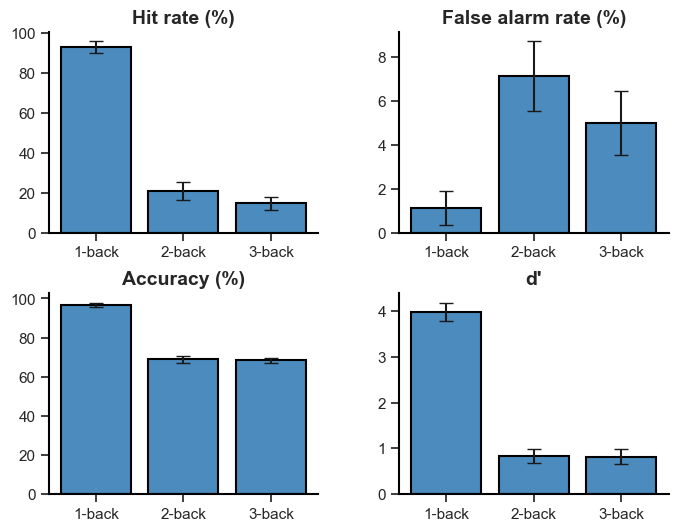

✅ 图片已保存到: D:\ChatGPT-WM-main\ChatGPT-WM-main\experiments\figures\letter_nback_metrics.svg


In [8]:
def plot_metrics(summary_stats, n_list, ci_level=0.95):
    # Set seaborn style and font size
    sns.set(style="whitegrid")
    plt.rcParams.update({'font.size': 12})

    # Bar plot for accuracy, hit rate, false alarm rate, and d prime
    fig, axes = plt.subplots(2, 2, figsize=(8, 6))
    metrics = ["hit_rate", "false_alarm_rate","accuracy", "d_prime"]
    titles = ["Hit rate (%)", "False alarm rate (%)", "Accuracy (%)", "d'"]

    for i, ax in enumerate(axes.flat):
        metric = metrics[i]
        means = [summary_stats[n][metric]["mean"] for n in n_list]
        stderrs = [summary_stats[n][metric]["stderr"] for n in n_list]
        # Compute 95% confidence intervals
        critical_value = t.ppf((1 + ci_level) / 2, blocks - 1)
        cis = [critical_value * stderr for stderr in stderrs]
        # Choose either standard errors or confidence intervals for error bars
        error_bars = cis # Change this to 'stderrs' for standard errors

        # 修复：使用正确的颜色
        x_pos = range(len(n_list))
        bars = ax.bar(x_pos, means, yerr=error_bars, capsize=5,
                     color='#4B8BBE',  # 使用固定的蓝色
                     edgecolor='black', linewidth=1.5)

        # 设置x轴标签
        ax.set_xticks(x_pos)
        ax.set_xticklabels([f"{n}-back" for n in n_list])
        ax.set_title(titles[i], fontsize=14, fontweight='bold')
        ax.set_ylim(bottom=0)

        # 美化图形
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(False)

        # 设置轴线样式
        ax.spines['bottom'].set_linewidth(1.5)
        ax.spines['left'].set_linewidth(1.5)
        ax.spines['bottom'].set_color('black')
        ax.spines['left'].set_color('black')

        # 显示刻度线
        ax.tick_params(axis='both', which='both', bottom=True, left=True)

    # layout setting: adjust the space between subplots
    plt.subplots_adjust(wspace=0.3, hspace=0.3)
    plt.show()

    # save the figure to a svg file in the figures folder
    # 确保figures文件夹存在
    os.makedirs("figures", exist_ok=True)
    fig.savefig(os.path.join("figures", "letter_nback_metrics.svg"), format="svg")
    print(f"✅ 图片已保存到: {os.path.abspath(os.path.join('figures', 'letter_nback_metrics.svg'))}")

plot_metrics(summary_stats, n_list)

In [39]:
def statistical_test(summary_stats, raw_data, n_list, blocks, alpha=0.05):
    metrics = ["hit_rate", "false_alarm_rate", "accuracy", "d_prime"]

    for metric in metrics:
        print(f"ANOVA for {metric}:")

        # Prepare the data for ANOVA
        data = [np.array(raw_data[n][metric]) for n in n_list]

        # Perform ANOVA
        F, p = f_oneway(*data)

        # Calculate degrees of freedom
        df_between = len(n_list) - 1
        df_within = blocks * len(n_list) - len(n_list)

        # Calculate partial eta squared
        ss_total = np.sum([(d - np.mean(data))**2 for d in itertools.chain.from_iterable(data)])
        ss_effect = sum(blocks * (np.mean(data[i]) - np.mean(np.concatenate(data)))**2 for i in range(len(n_list)))
        partial_eta_squared = ss_effect / (ss_effect + ss_total)

        print(f"  F({df_between}, {df_within}) = {F:.4f}, p = {p:.4f}, partial eta squared = {partial_eta_squared:.4f}")

        # Perform post-hoc t-tests
        print("  Post-hoc t-tests:")
        for combo in itertools.combinations(n_list, 2):
            n1, n2 = combo
            data1 = raw_data[n1][metric]
            data2 = raw_data[n2][metric]

            # t-test
            t_stat, p_value = ttest_ind(data1, data2)

            # Calculate degrees of freedom for t-test
            df_t = 2 * blocks - 2

            # Bonferroni correction
            corrected_p = min(p_value * len(list(itertools.combinations(n_list, 2))), 1)

            # Calculate Cohen's d
            pooled_std = np.sqrt((np.std(data1)**2 + np.std(data2)**2) / 2)
            cohen_d = (np.mean(data1) - np.mean(data2)) / pooled_std

            print(f"    {n1}-back vs {n2}-back: t({df_t}) = {t_stat:.4f}, p = {corrected_p:.4f}, Cohen's d = {cohen_d:.4f}")

        print()

statistical_test(summary_stats, raw_data, n_list, blocks)

ANOVA for hit_rate:
  F(2, 147) = 575.4536, p = 0.0000, partial eta squared = 0.4700
  Post-hoc t-tests:
    1-back vs 2-back: t(98) = 27.0367, p = 0.0000, Cohen's d = 5.4622
    1-back vs 3-back: t(98) = 35.6131, p = 0.0000, Cohen's d = 7.1949
    2-back vs 3-back: t(98) = 2.2383, p = 0.0824, Cohen's d = 0.4522

ANOVA for false_alarm_rate:
  F(2, 147) = 20.8808, p = 0.0000, partial eta squared = 0.1812
  Post-hoc t-tests:
    1-back vs 2-back: t(98) = -6.7607, p = 0.0000, Cohen's d = -1.3659
    1-back vs 3-back: t(98) = -4.6594, p = 0.0000, Cohen's d = -0.9413
    2-back vs 3-back: t(98) = 1.9561, p = 0.1599, Cohen's d = 0.3952

ANOVA for accuracy:
  F(2, 147) = 515.5811, p = 0.0000, partial eta squared = 0.4667
  Post-hoc t-tests:
    1-back vs 2-back: t(98) = 28.1078, p = 0.0000, Cohen's d = 5.6786
    1-back vs 3-back: t(98) = 31.4295, p = 0.0000, Cohen's d = 6.3497
    2-back vs 3-back: t(98) = 0.5867, p = 1.0000, Cohen's d = 0.1185

ANOVA for d_prime:
  F(2, 147) = 421.9976, p =

In [40]:
# check the normality of the data
def check_normality(raw_data, n_list, blocks):
    metrics = ["hit_rate", "false_alarm_rate", "accuracy", "d_prime"]

    for metric in metrics:
        print(f"Normality test for {metric}:")

        # Prepare the data for normality test
        data = [np.array(raw_data[n][metric]) for n in n_list]

        # Perform normality test
        W, p = shapiro(np.concatenate(data))

        print(f"  W = {W:.4f}, p = {p:.4f}")

        print()

check_normality(raw_data, n_list, blocks)


Normality test for hit_rate:
  W = 0.8044, p = 0.0000

Normality test for false_alarm_rate:
  W = 0.7697, p = 0.0000

Normality test for accuracy:
  W = 0.8435, p = 0.0000

Normality test for d_prime:
  W = 0.8462, p = 0.0000



In [41]:
# check the homogeneity of the variance
def check_homogeneity(raw_data, n_list, blocks):
    metrics = ["hit_rate", "false_alarm_rate", "accuracy", "d_prime"]

    for metric in metrics:
        print(f"Levene's test for {metric}:")

        # Prepare the data for homogeneity test
        data = [np.array(raw_data[n][metric]) for n in n_list]

        # Perform homogeneity test
        W, p = levene(*data)

        print(f"  W = {W:.4f}, p = {p:.4f}")

        print()

check_homogeneity(raw_data, n_list, blocks)


Levene's test for hit_rate:
  W = 1.6578, p = 0.1941

Levene's test for false_alarm_rate:
  W = 12.7525, p = 0.0000

Levene's test for accuracy:
  W = 2.8613, p = 0.0604

Levene's test for d_prime:
  W = 5.3038, p = 0.0060



Distribution plot for hit_rate:
✅ 图片已保存到: D:\ChatGPT-WM-main\ChatGPT-WM-main\experiments\figures\distribution_hit_rate.svg


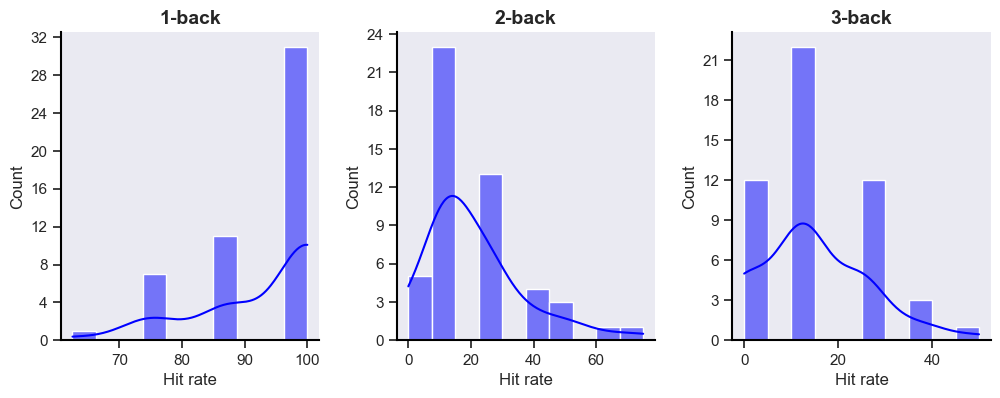

Distribution plot for false_alarm_rate:
✅ 图片已保存到: D:\ChatGPT-WM-main\ChatGPT-WM-main\experiments\figures\distribution_false_alarm_rate.svg


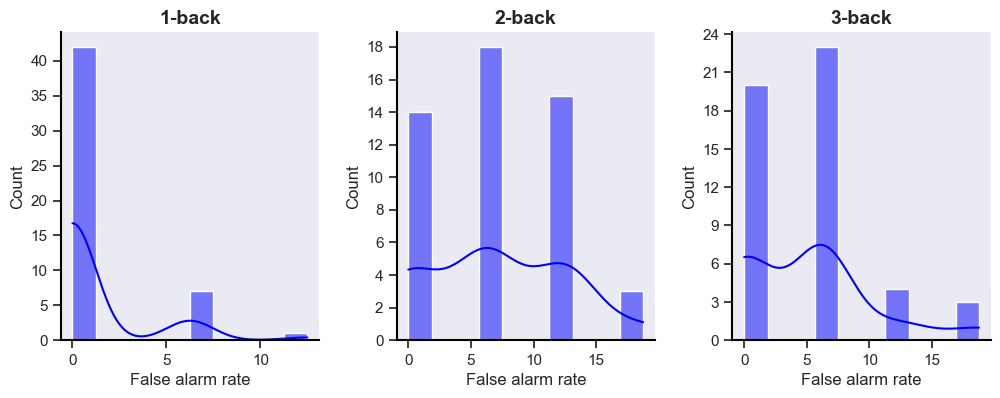

Distribution plot for accuracy:
✅ 图片已保存到: D:\ChatGPT-WM-main\ChatGPT-WM-main\experiments\figures\distribution_accuracy.svg


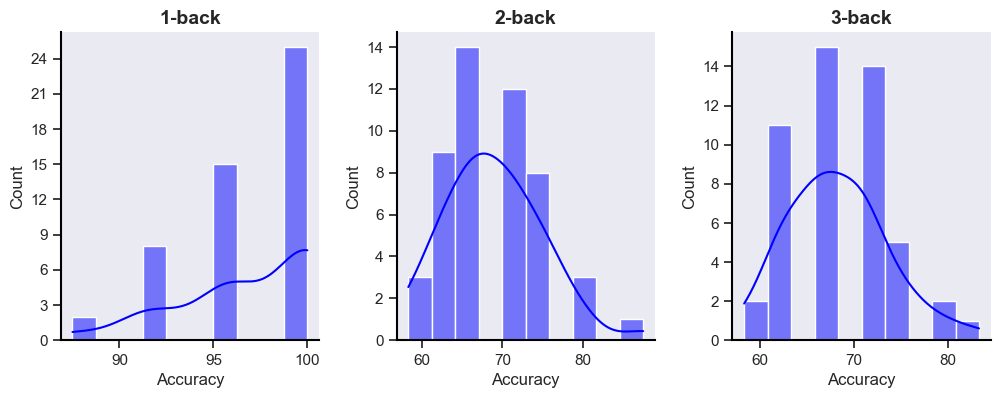

Distribution plot for d_prime:
✅ 图片已保存到: D:\ChatGPT-WM-main\ChatGPT-WM-main\experiments\figures\distribution_d_prime.svg


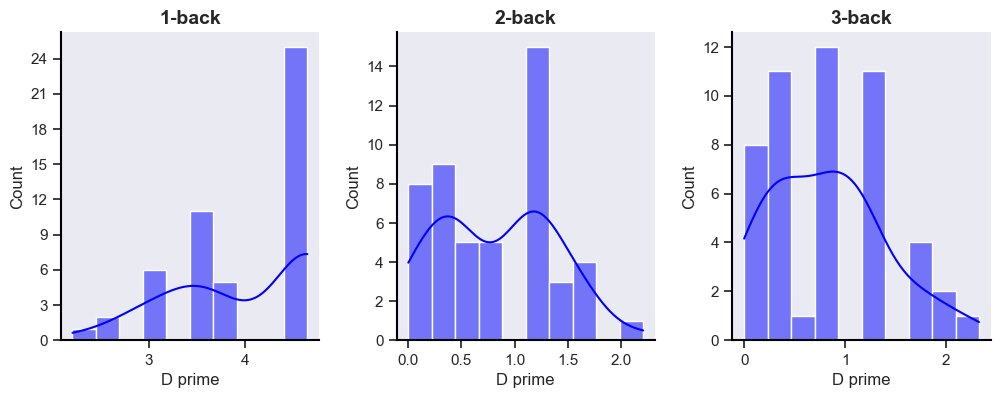

In [9]:
# plot the distribution of the data
def plot_distribution(raw_data, n_list, blocks):
    metrics = ["hit_rate", "false_alarm_rate", "accuracy", "d_prime"]

    for metric in metrics:
        print(f"Distribution plot for {metric}:")

        # Prepare the data for distribution plot
        data = [np.array(raw_data[n][metric]) for n in n_list]

        # Perform distribution plot
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        for i, ax in enumerate(axes.flat):
            sns.histplot(data[i], ax=ax, color="blue", bins=10, kde=True, stat='count')
            # sns.displot(data[i], ax=ax, kde=True, color="black")
            # sns.distplot(data[i], ax=ax, color="blue")
            ax.set_title(f"{n_list[i]}-back", fontsize=14, fontweight='bold')
            ax.set_xlabel(metric.replace("_", " ").capitalize())
            ax.set_ylabel("Count")
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            # remove the grid lines
            ax.grid(False)
            # set the weight  and color of axes lines
            ax.spines['bottom'].set_linewidth(1.5)
            ax.spines['left'].set_linewidth(1.5)
            ax.spines['bottom'].set_color('black')
            ax.spines['left'].set_color('black')
            # show tick lines on the left and bottom axes
            ax.tick_params(axis='both', which='both', bottom=True, left=True)
            # set y ticks to be integers
            ax.yaxis.set_major_locator(MaxNLocator(integer=True))

        # 确保figures文件夹存在
        os.makedirs("figures", exist_ok=True)

        # 保存图片
        filename = f"figures/distribution_{metric}.svg"
        fig.savefig(filename, format="svg", bbox_inches='tight')
        print(f"✅ 图片已保存到: {os.path.abspath(filename)}")

        # layout setting: adjust the space between subplots
        plt.subplots_adjust(wspace=0.3, hspace=0.3)
        plt.show()

plot_distribution(raw_data, n_list, blocks)

In [45]:
# As normality test and homogeneity test show that the data is not normal and the variance is not homogeneous, we use the non-parametric test
def nonparametric_test(summary_stats, raw_data, n_list, blocks, alpha=0.05):
    metrics = ["hit_rate", "false_alarm_rate", "accuracy", "d_prime"]

    for metric in metrics:
        print(f"Kruskal-Wallis test for {metric}:")

        # Prepare the data for Kruskal-Wallis test
        data = [np.array(raw_data[n][metric]) for n in n_list]

        # Perform Kruskal-Wallis test
        H, p = kruskal(*data)

        # Calculate degrees of freedom
        df = len(n_list) - 1

        # Calculate the total number of observations
        N = len(raw_data[n_list[0]][metric]) * len(n_list)
        
        # Calculate epsilon squared (ε²):ε² = (H - k + 1) / (N - k), where H is the Kruskal-Wallis H statistic, k is the number of groups (in your case, len(n_list)), N is the total number of observations across all groups
        epsilon_squared = (H - len(n_list) + 1) / (N - len(n_list))

        print(f"  H({df}) = {H:.4f}, p = {p:.4f}, epsilon squared = {epsilon_squared:.4f}")

        # Perform post-hoc Mann-Whitney U test
        print("  Post-hoc Mann-Whitney U test:")
        for combo in itertools.combinations(n_list, 2):
            n1, n2 = combo
            data1 = raw_data[n1][metric]
            data2 = raw_data[n2][metric]

            # Mann-Whitney U test
            U, p_value = mannwhitneyu(data1, data2)

            # Bonferroni correction
            corrected_p = min(p_value * len(list(itertools.combinations(n_list, 2))), 1)

            # Calculate the effect size using the rank-biserial correlation (r): r = 1 – (2U)/ (n1 * n2)
            r = 1 - (2 * U) / (len(data1) * len(data2))

            print(f"    {n1}-back vs {n2}-back: U = {U:.4f}, p = {corrected_p:.4f}, rank-biserial correlation(r) = {r:.4f}")

        print()

nonparametric_test(summary_stats, raw_data, n_list, blocks)

Kruskal-Wallis test for hit_rate:
  H(2) = 104.9501, p = 0.0000, epsilon squared = 0.7003
  Post-hoc Mann-Whitney U test:
    1-back vs 2-back: U = 2495.0000, p = 0.0000, rank-biserial correlation(r) = -0.9960
    1-back vs 3-back: U = 2500.0000, p = 0.0000, rank-biserial correlation(r) = -1.0000
    2-back vs 3-back: U = 1517.5000, p = 0.1524, rank-biserial correlation(r) = -0.2140

Kruskal-Wallis test for false_alarm_rate:
  H(2) = 36.7075, p = 0.0000, epsilon squared = 0.2361
  Post-hoc Mann-Whitney U test:
    1-back vs 2-back: U = 494.5000, p = 0.0000, rank-biserial correlation(r) = 0.6044
    1-back vs 3-back: U = 685.5000, p = 0.0000, rank-biserial correlation(r) = 0.4516
    2-back vs 3-back: U = 1527.5000, p = 0.1270, rank-biserial correlation(r) = -0.2220

Kruskal-Wallis test for accuracy:
  H(2) = 101.5477, p = 0.0000, epsilon squared = 0.6772
  Post-hoc Mann-Whitney U test:
    1-back vs 2-back: U = 2499.0000, p = 0.0000, rank-biserial correlation(r) = -0.9992
    1-back vs